# Curso de Machine Learning - YouTube

Esse é um cruso de Machine Learning disponível no [YouTube](https://www.youtube.com/watch?v=80B4Ze11qWw&list=PLvlkVRRKOYFR6_LmNcJliicNan2TYeFO2&index=3). O curso é uma introdução a Machine Learning.
Abaixo estão os códigos e anotações feitas durante o curso. O curso é em português, mas os códigos estão em inglês, pois é a língua mais utilizada na área de Machine Learning.

---

## Aula - 3 (Classificação de frutas utilizando Decision Tree)

In [299]:
import pandas as pd
from sklearn import tree
from pathlib import Path
import matplotlib.pyplot as plt

In [300]:
data_path = Path.cwd() / "data" / "dados_frutas.xlsx"
df = pd.read_excel(data_path)
df

,Arredondada,Suculenta,Vermelha,Doce,Fruta
0,0,1,1,1,Morango
1,1,0,0,0,Limão
2,1,1,0,1,Pera
3,0,0,0,1,Banana
4,1,1,1,1,Cereja
5,1,1,1,0,Tomate
6,1,1,1,1,Maçã


Instanciando a árvore de decisão para classificar frutas.

In [301]:
tree_clf = tree.DecisionTreeClassifier(random_state=42)

Criando o modelo de árvore de decisão e treinando-o com os dados de frutas. O modelo é treinado usando o método `fit`, que recebe os dados de treinamento (features) e as classes correspondentes (labels). O modelo aprende a partir desses dados e pode ser usado para fazer previsões em novos dados. Cada **sample** é uma linha da tabela, ou seja, uma instância.

d:\projetos\machine_learning_study\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


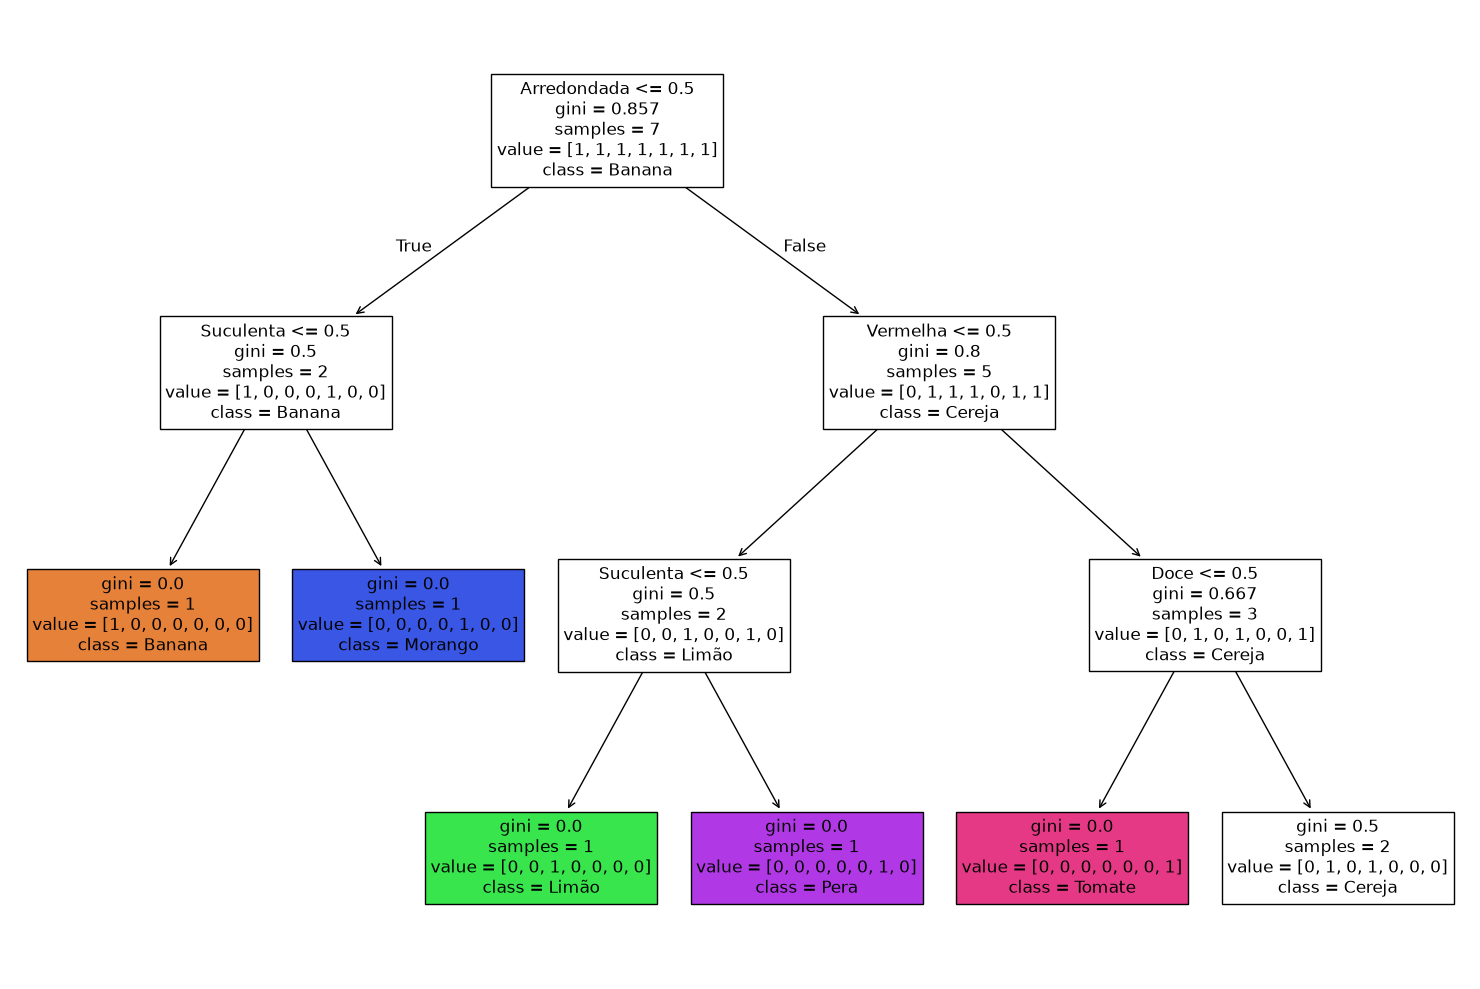

In [302]:
FEATURES = df[[
    "Arredondada",
    "Suculenta",
    "Vermelha",
    "Doce"
]]

X_train = FEATURES
y_train = df["Fruta"]

tree_clf.fit(X_train, y_train)

tree_clf.predict([[0, 1, 0, 1]])

# Passando as classes para o `plot_tree` como uma lista de strings
class_names = [str(classe) for classe in tree_clf.classes_]

plt.figure(figsize=(15, 10), dpi=100)
tree.plot_tree(
    tree_clf,
    feature_names=FEATURES.columns.tolist(),
    class_names=class_names,
    filled=True,
    fontsize=12
)
plt.tight_layout()
plt.show()


In [303]:
df.sort_values("Fruta").reset_index(drop=True)

,Arredondada,Suculenta,Vermelha,Doce,Fruta
0,0,0,0,1,Banana
1,1,1,1,1,Cereja
2,1,0,0,0,Limão
3,1,1,1,1,Maçã
4,0,1,1,1,Morango
5,1,1,0,1,Pera
6,1,1,1,0,Tomate


In [304]:
# FEATURES.columns.tolist()
# tree_clf.classes_.__len__()
pd.Series(
    tree_clf.predict_proba([[0, 1, 0, 1]])[0],
    index=tree_clf.classes_
)

d:\projetos\machine_learning_study\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Banana     0.0
Cereja     0.0
Limão      0.0
Maçã       0.0
Morango    1.0
Pera       0.0
Tomate     0.0
dtype: float64

## Aula - 4

Nessa aula está sendo usado um dataset com os dados de cerveja (`dados_cerveja.xlsx`).

In [305]:
data_path = Path.cwd() / "data" / "dados_cerveja.xlsx"
df = pd.read_excel(data_path)
df

,id,temperatura,copo,espuma,cor,classe
0,1,-5,mud,não,escura,weissbier
1,2,-5,mud,sim,escura,weissbier
2,3,-1,pint,não,clara,weissbier
3,4,-1,pint,sim,clara,weissbier
4,5,-5,pint,não,escura,pale-ale
5,6,-5,pint,não,clara,pale-ale
6,7,-5,pint,sim,escura,pale-ale
7,8,-1,mud,não,clara,pilsen
8,9,-5,mud,não,clara,pilsen
9,10,-1,mud,sim,clara,pilsen


Nesse caso, é possível observar que temos features que não são numéricas, ou seja, são do tipo `object` ou `string`. Para usar esses dados em um modelo de Machine Learning como a árvore de decisão, é necessário convertê-los para um formato numérico. Isso pode ser feito usando técnicas como **one-hot encoding** ou **label encoding**.

Entendedo os tipos de variáveis (quantitativas e qualitativas):

<div style="width: 700px; margin: 0 auto; text-align: center;">

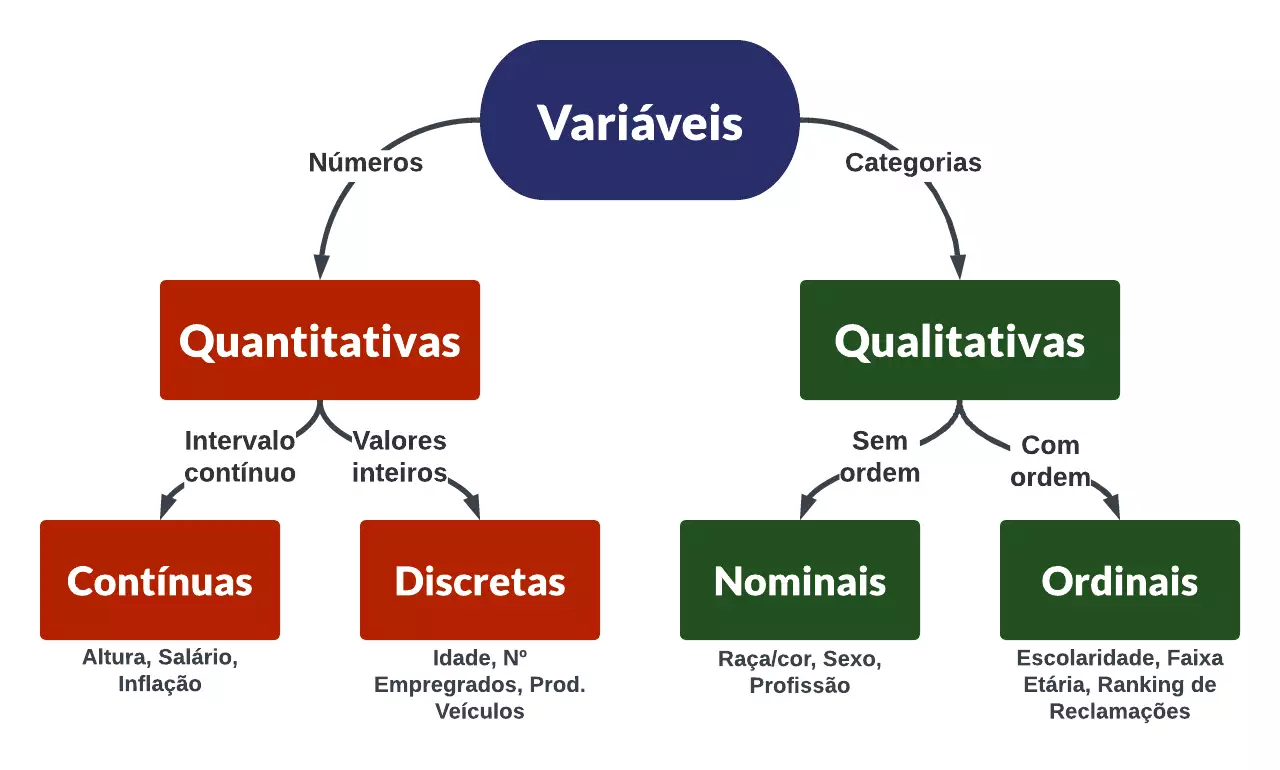

</div>

Criando as variáveis `X_train` e `y_train` a partir do DataFrame `df`. A variável `X_train` contém as features (colunas "temperatura", "copo", "espuma" e "cor"), enquanto a variável `y_train` contém as classes (label).

In [306]:
FEATURES = df[[
    "temperatura",
    "copo",
    "espuma",
    "cor"
]]


In [307]:
FEATURES.dtypes

temperatura    int64
copo             str
espuma           str
cor              str
dtype: object

In [308]:
FEATURES.select_dtypes(include=["object", "string"])


,copo,espuma,cor
0,mud,não,escura
1,mud,sim,escura
2,pint,não,clara
3,pint,sim,clara
4,pint,não,escura
5,pint,não,clara
6,pint,sim,escura
7,mud,não,clara
8,mud,não,clara
9,mud,sim,clara


Outra forma de fazer `one-hot-encoding` com Pandas é usando a função `get_dummies()`.

In [309]:
data_path = Path.cwd() / "data" / "dados_cerveja.xlsx"
df = pd.read_excel(data_path)

In [310]:
FEATURES = df[[
    "temperatura",
    "copo",
    "espuma",
    "cor"
]]


In [311]:
encoded_df = pd.get_dummies(
    FEATURES,
    columns=["espuma"],
    prefix="espuma",
    dtype=int
)
encoded_df

,temperatura,copo,cor,espuma_não,espuma_sim
0,-5,mud,escura,1,0
1,-5,mud,escura,0,1
2,-1,pint,clara,1,0
3,-1,pint,clara,0,1
4,-5,pint,escura,1,0
5,-5,pint,clara,1,0
6,-5,pint,escura,0,1
7,-1,mud,clara,1,0
8,-5,mud,clara,1,0
9,-1,mud,clara,0,1


In [312]:
data_path = Path.cwd() / "data" / "dados_cerveja.xlsx"
df = pd.read_excel(data_path)

In [313]:
FEATURES = df[[
    "temperatura",
    "copo",
    "espuma",
    "cor"
]]

LABEL = df["classe"]

FEATURES.dtypes

temperatura    int64
copo             str
espuma           str
cor              str
dtype: object

In [314]:
FEATURES

,temperatura,copo,espuma,cor
0,-5,mud,não,escura
1,-5,mud,sim,escura
2,-1,pint,não,clara
3,-1,pint,sim,clara
4,-5,pint,não,escura
5,-5,pint,não,clara
6,-5,pint,sim,escura
7,-1,mud,não,clara
8,-5,mud,não,clara
9,-1,mud,sim,clara


In [315]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
encoded = encoder.fit_transform(FEATURES[["copo", "espuma", "cor"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["copo", "espuma", "cor"])
)
FEATURES = pd.concat([FEATURES.drop(["copo", "espuma", "cor"], axis=1), encoded_df], axis=1).astype(int)

In [316]:
encoded.shape

(12, 3)

In [317]:
encoded

array([[0., 0., 1.],
       [0., 1., 1.],
       [1., 0., 0.],
       [1., 1., 0.],
       [1., 0., 1.],
       [1., 0., 0.],
       [1., 1., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 1.]])

In [318]:
FEATURES.dtypes

temperatura    int64
copo           int64
espuma         int64
cor            int64
dtype: object

In [319]:
FEATURES

,temperatura,copo,espuma,cor
0,-5,0,0,1
1,-5,0,1,1
2,-1,1,0,0
3,-1,1,1,0
4,-5,1,0,1
5,-5,1,0,0
6,-5,1,1,1
7,-1,0,0,0
8,-5,0,0,0
9,-1,0,1,0


Agora, vamos treinar o modelo de árvore de decisão usando as variáveis `X_train` e `y_train`.

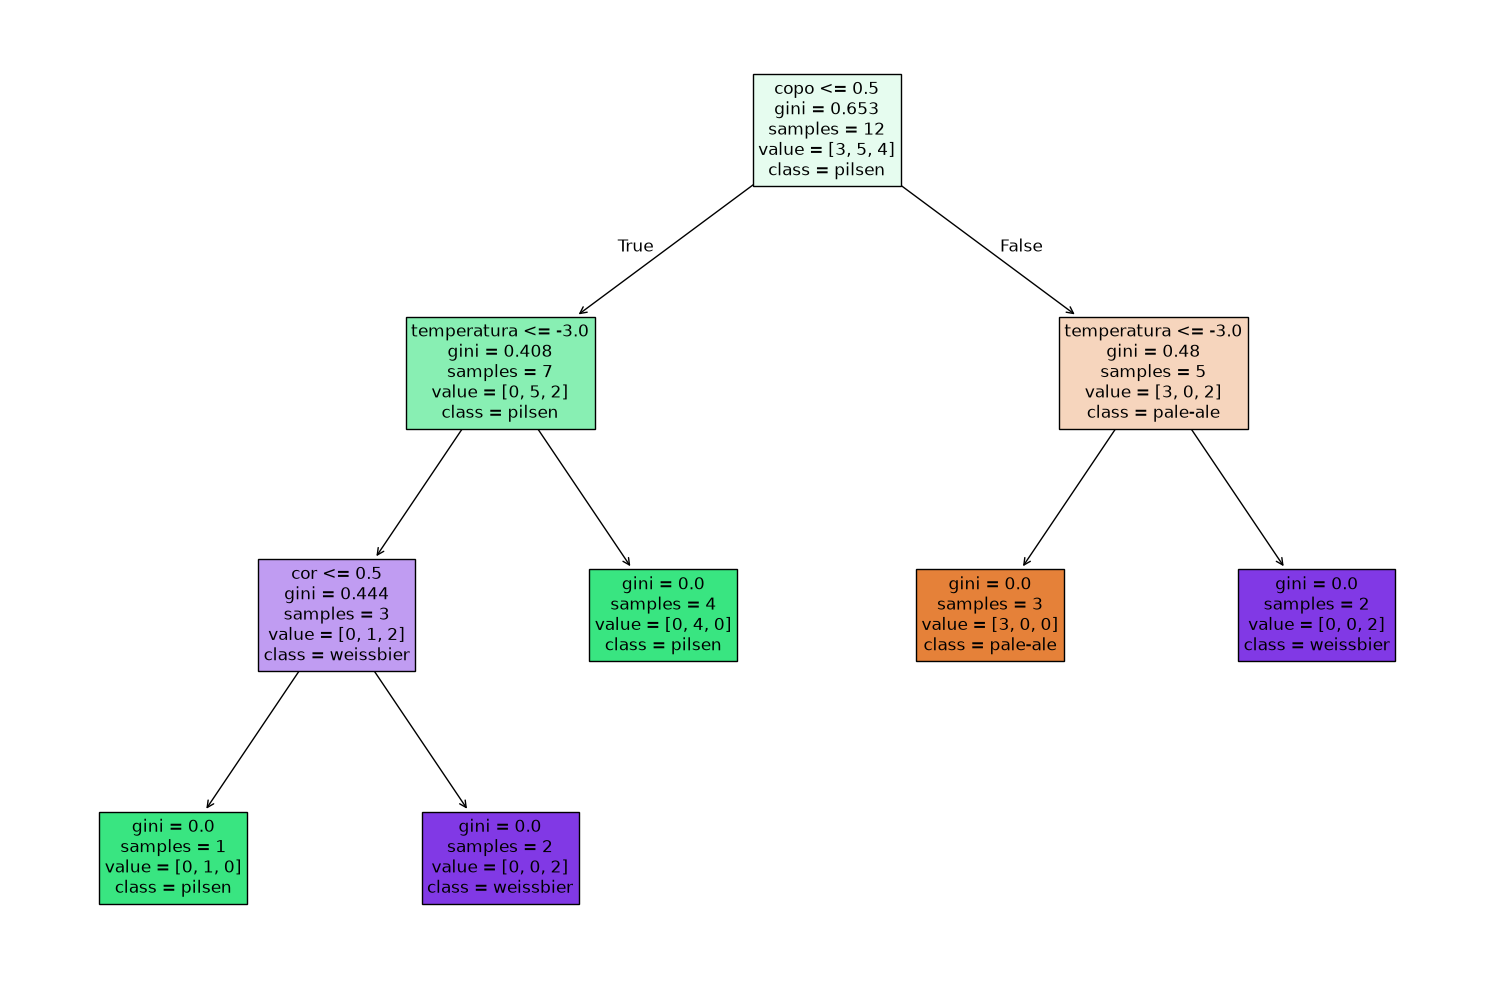

In [320]:
X_train = FEATURES
y_train = LABEL

tree_clf = tree.DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

# Vamos mostrar a árvore de decisão treinada usando a função `plot_tree`.

# Passando as classes para o `plot_tree` como uma lista de strings
class_names = [str(classe) for classe in tree_clf.classes_]

plt.figure(figsize=(15, 10), dpi=100)
tree.plot_tree(
    tree_clf,
    feature_names=FEATURES.columns.tolist(),
    class_names=class_names,
    filled=True,
    fontsize=12
)
plt.tight_layout()
plt.show()

In [321]:
df.sort_values("classe").reset_index(drop=True)

,id,temperatura,copo,espuma,cor,classe
0,5,-5,pint,não,escura,pale-ale
1,6,-5,pint,não,clara,pale-ale
2,7,-5,pint,sim,escura,pale-ale
3,8,-1,mud,não,clara,pilsen
4,9,-5,mud,não,clara,pilsen
5,10,-1,mud,sim,clara,pilsen
6,11,-1,mud,não,escura,pilsen
7,12,-1,mud,sim,escura,pilsen
8,1,-5,mud,não,escura,weissbier
9,2,-5,mud,sim,escura,weissbier


In [322]:
pd.Series(
    tree_clf.predict_proba([[-5, 0, 1, 1]])[0],
    index=tree_clf.classes_
)

d:\projetos\machine_learning_study\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


pale-ale     0.0
pilsen       0.0
weissbier    1.0
dtype: float64

In [323]:
pd.concat([FEATURES, LABEL], axis=1).sort_values("classe").reset_index(drop=True)

,temperatura,copo,espuma,cor,classe
0,-5,1,0,1,pale-ale
1,-5,1,0,0,pale-ale
2,-5,1,1,1,pale-ale
3,-1,0,0,0,pilsen
4,-5,0,0,0,pilsen
5,-1,0,1,0,pilsen
6,-1,0,0,1,pilsen
7,-1,0,1,1,pilsen
8,-5,0,0,1,weissbier
9,-5,0,1,1,weissbier


## Aula - 5

Nessa aula está sendo usado o dataset `dados_clones.parquet`.

In [324]:
data_path = Path.cwd() / "data" / "dados_clones.parquet"
df = pd.read_parquet(data_path)
df

,p2o_master_id,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso
...,...,...,...,...,...,...,...,...,...
1048714,10230117,84.14,Yoda,181.03,Tipo 2,Tipo 1,Tipo 2,51.3,Apto
1048715,10230118,83.10,Yoda,180.62,Tipo 2,Tipo 1,Tipo 3,3.3,Apto
1048716,10230119,83.63,Obi-Wan Kenobi,180.54,Tipo 5,Tipo 2,Tipo 5,40.1,Apto
1048717,10230120,83.02,Shaak Ti,180.06,Tipo 1,Tipo 4,Tipo 1,11.2,Apto


In [325]:
df.columns = df.columns.str.strip().str.lower()
df

,p2o_master_id,massa(em kilos),general jedi encarregado,estatura(cm),distância ombro a ombro,tamanho do crânio,tamanho dos pés,tempo de existência(em meses),status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso
...,...,...,...,...,...,...,...,...,...
1048714,10230117,84.14,Yoda,181.03,Tipo 2,Tipo 1,Tipo 2,51.3,Apto
1048715,10230118,83.10,Yoda,180.62,Tipo 2,Tipo 1,Tipo 3,3.3,Apto
1048716,10230119,83.63,Obi-Wan Kenobi,180.54,Tipo 5,Tipo 2,Tipo 5,40.1,Apto
1048717,10230120,83.02,Shaak Ti,180.06,Tipo 1,Tipo 4,Tipo 1,11.2,Apto


Pegando apenas as futures que serão usadas para treinar o modelo de árvore de decisão. As features selecionadas são: "massa" e "estatura".

In [326]:
features = df[[
    "massa(em kilos)",
    "estatura(cm)"
]]

features

,massa(em kilos),estatura(cm)
0,83.13,180.25
1,83.08,180.39
2,83.12,180.26
3,83.38,180.35
4,83.15,180.31
...,...,...
1048714,84.14,181.03
1048715,83.10,180.62
1048716,83.63,180.54
1048717,83.02,180.06


Agora, vamos escolher a veriável label (que contem as classes) que será usada para treinar o modelo de árvore de decisão. A variável label escolhida é a `status`.

In [327]:
label = df['status']

Vamos treinar o modelo de árvore de decisão usando as variáveis `features` e `label`.

In [328]:
pd.concat([features, label], axis=1).sort_values("status").reset_index(drop=True)

,massa(em kilos),estatura(cm),status
0,84.40,180.84,Apto
1,83.71,181.19,Apto
2,83.10,180.59,Apto
3,84.47,180.96,Apto
4,84.21,180.29,Apto
...,...,...,...
1048714,83.25,180.27,Defeituoso
1048715,83.13,180.38,Defeituoso
1048716,83.37,180.30,Defeituoso
1048717,83.30,180.40,Defeituoso


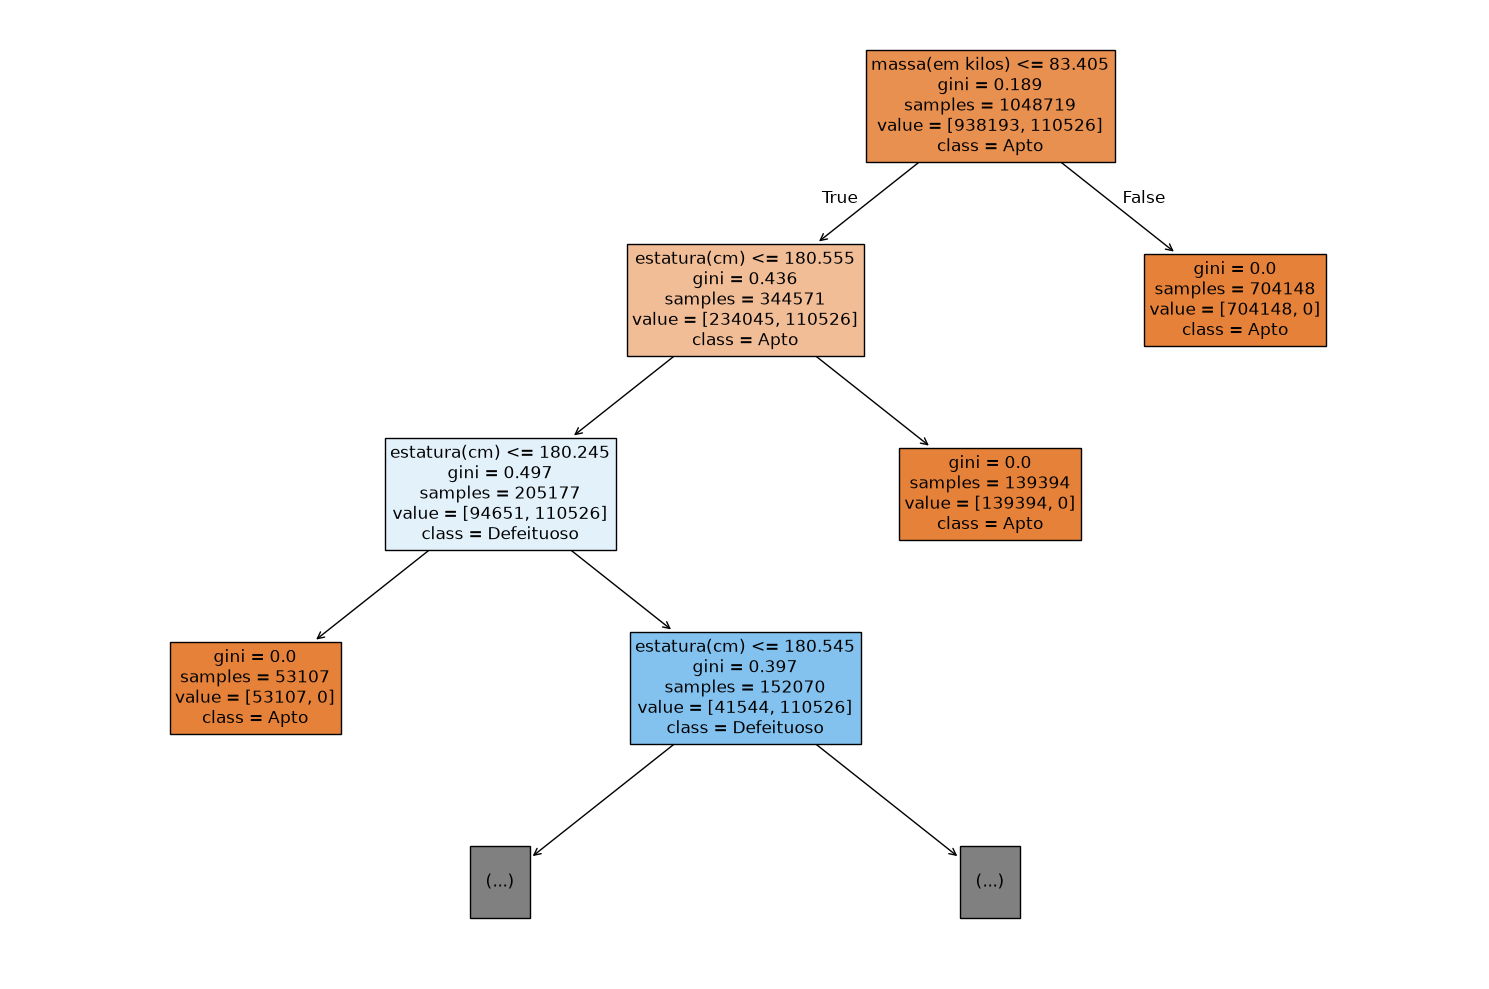

In [329]:
X_train = features
y_train = label

tree_clf = tree.DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

# Montando a árvore de decisão treinada usando a função `plot_tree`.

# Passando as classes para o `plot_tree` como uma lista de strings
class_names = [str(classe) for classe in tree_clf.classes_]

plt.figure(figsize=(15, 10), dpi=100)
tree.plot_tree(
    tree_clf,
    feature_names=features.columns.tolist(),
    class_names=class_names,
    max_depth=3,
    filled=True,
    fontsize=12
)
plt.tight_layout()
plt.show()

In [330]:
df.groupby("status")[["massa(em kilos)", "estatura(cm)"]].mean()

,massa(em kilos),estatura(cm)
status,,
Apto,83.765887,180.605545
Defeituoso,83.200134,180.400186


## Aula - 6

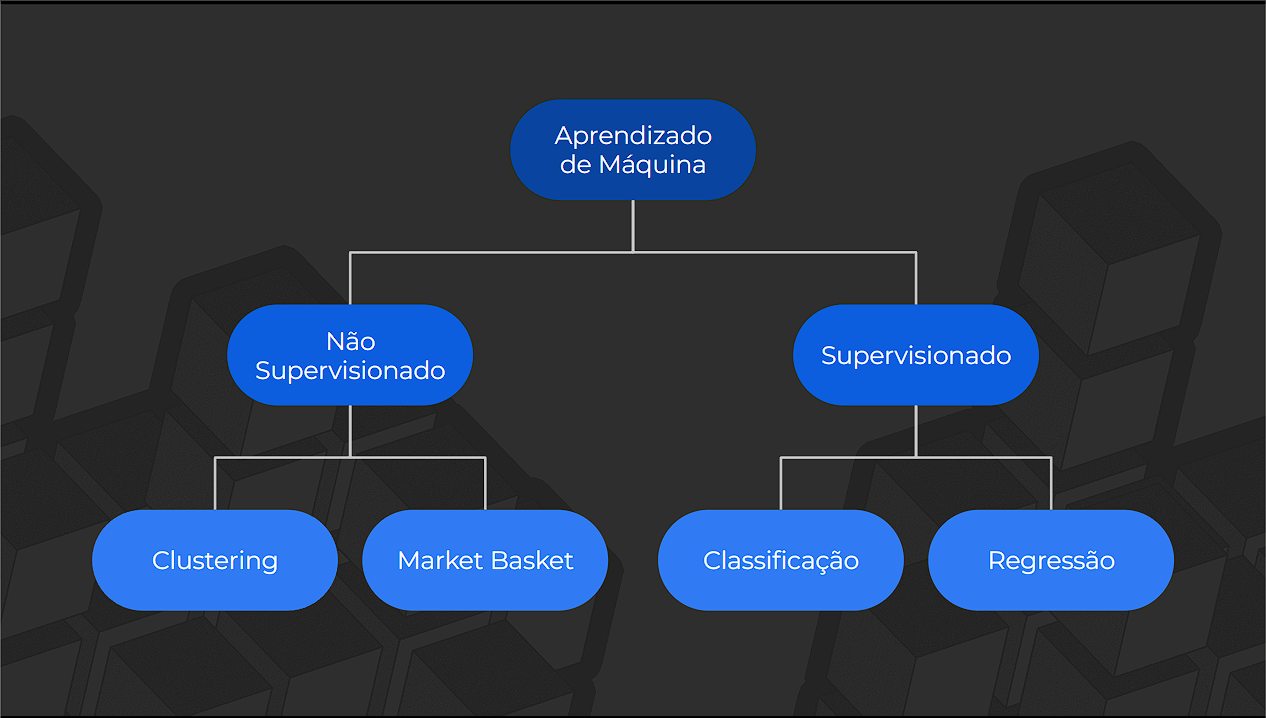

### Aprendizagem supervisionada

**Aprendizado supervisionado** é quando temos um conjunto de dados rotulado, ou seja, cada instância do conjunto de dados possui uma classe associada. O modelo aprende a partir desses dados e pode ser usado para fazer previsões em novos dados, e não necessita dos dados anteriores para fazer previsões. O modelo é treinado usando o método `fit`, **que recebe os dados de treinamento (features)** e as **classes correspondentes (labels)**. O modelo aprende a partir desses dados e pode ser usado para fazer previsões em novos dados.

**Aprendizado não supervisionado** é quando temos um conjunto de dados não rotulado, ou seja, cada instância do conjunto de dados não possui uma classe associada. O modelo aprende a partir desses dados e pode ser usado para fazer previsões em novos dados, mas precisa dos dados anteriores para fazer previsões. O modelo é treinado usando o método `fit`, **que recebe apenas os dados de treinamento (features)**, ou seja, não possui labels/target. O modelo aprende a partir desses dados e pode ser usado para fazer previsões em novos dados.

### Método dos mínimos quadrados

O método dos mínimos quadrados é uma técnica matemática usada para encontrar a reta que minimiza a soma dos quadrados das diferenças entre os valores observados e os valores previstos pela reta, ou seja, encontrar a menor distância entre os pontos em relação à reta.

Previsão: $\hat{y} = ax + b$

Erro: $e = y - \hat{y}$, onde $y$ é o valor observado e $\hat{y}$ é o valor previsto pela reta.

Soma dos quadrados dos erros: $S = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

Quando usamos o erro absoluto, estamos minimizando a soma dos erros absolutos, ou seja, a soma das diferenças entre os valores observados e os valores previstos pela reta, sem considerar o sinal da diferença. Isso significa que estamos tratando todos os erros da mesma forma, independentemente de serem positivos ou negativos.

Isso garante que os erros positivos e negativos não se cancelem, por exemplo, se tivermos uma previsão de $150$ e o valor real for $100$, o erro será $50$. Se tivermos uma previsão de $50$ e o valor real for $100$, o erro será $-50$. A soma dos erros será $0$, mas a soma dos erros absolutos será $100$.

Para encontrar o ponto de mínimo da soma dos quadrados dos erros, podemos derivar a função de erro em relação aos parâmetros da reta $a$ e $b$ e igualar a zero. Isso nos dá um sistema de equações que podemos resolver para encontrar os valores de $a$ e $b$ que minimizam a soma dos quadrados dos erros.

Derivada parcial em relação a $a$: 

$$\frac{\partial S}{\partial a} = -2 \sum_{i=1}^{n} x_i (y_i - (ax_i + b)) = 0$$

Derivada parcial em relação a $b$:

$$\frac{\partial S}{\partial b} = -2 \sum_{i=1}^{n} (y_i - (ax_i + b)) = 0$$

## Aula - 9 (Regressão Linear e Árvore de Decisão)

Primeiro, vamos treinar um modelo de regressão linear usando o dataset `dados_cerveja.xlsx`.

In [331]:
data_path = Path.cwd() / "data" / "dados_cerveja_nota.xlsx"
df = pd.read_excel(data_path)
df = df.set_index("id")

In [332]:
df.head()

,cerveja,nota
id,,
1,1,0.75
2,1,3.00
3,2,1.75
4,3,1.75
5,4,4.20


In [333]:
from sklearn.linear_model import LinearRegression

In [334]:
# X_train é uma matriz com uma única coluna, que é a coluna "cerveja" do DataFrame.
# y_train é um vetor que contém os valores da coluna "nota" do DataFrame.
X_train, y_train = df[["cerveja"]], df["nota"]

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cerveja']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1516
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [335]:
(regression_model.coef_, regression_model.intercept_)

(array([1.03629032]), np.float64(0.151612903225808))

In [336]:
print(f"Coeficiente angular: {regression_model.coef_[0]:.2f}")
print(f"Coeficiente linear: {regression_model.intercept_:.2f}")

Coeficiente angular: 1.04
Coeficiente linear: 0.15


In [337]:
predict_reg = regression_model.predict(X_train.drop_duplicates())

### Modelo de Regressão Linear

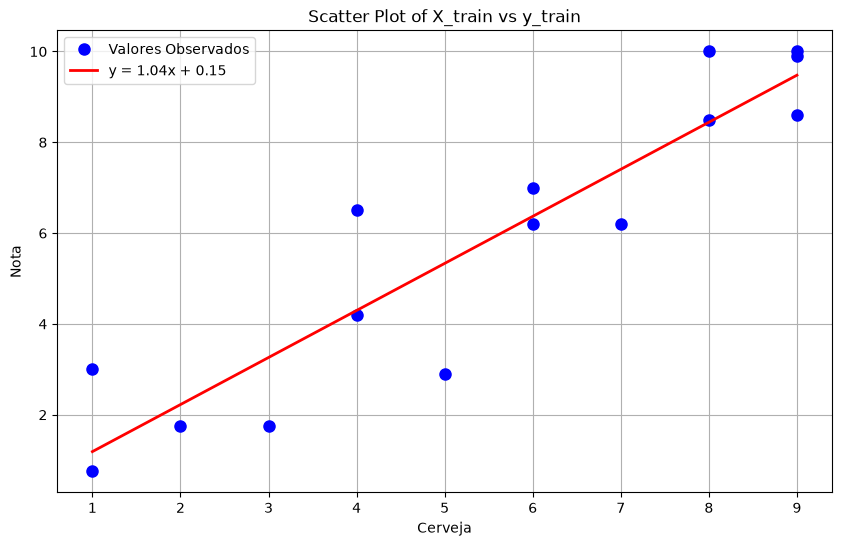

In [338]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(
    X_train,
    y_train,
    'o',
    markersize=8,
    color='blue'
)
plt.xlabel('Cerveja')
plt.ylabel('Nota')
plt.title('Scatter Plot of X_train vs y_train')
plt.grid(True)
plt.plot(
    X_train.drop_duplicates(),
    predict_reg,
    color='red',
    linewidth=2
)
plt.legend([
    "Valores Observados",
    f"y = {regression_model.coef_[0]:.2f}x + {regression_model.intercept_:.2f}"
])
plt.show()

### Modelo de Árvore de Decisão com Regressão Linear

In [339]:
tree_reg_1 = tree.DecisionTreeRegressor(random_state=42)
tree_reg_1.fit(X_train, y_train)

tree_reg_2 = tree.DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg_2.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [340]:
predict_tree_reg_1 = tree_reg_1.predict(X_train.drop_duplicates())
predict_tree_reg_2 = tree_reg_2.predict(X_train.drop_duplicates())

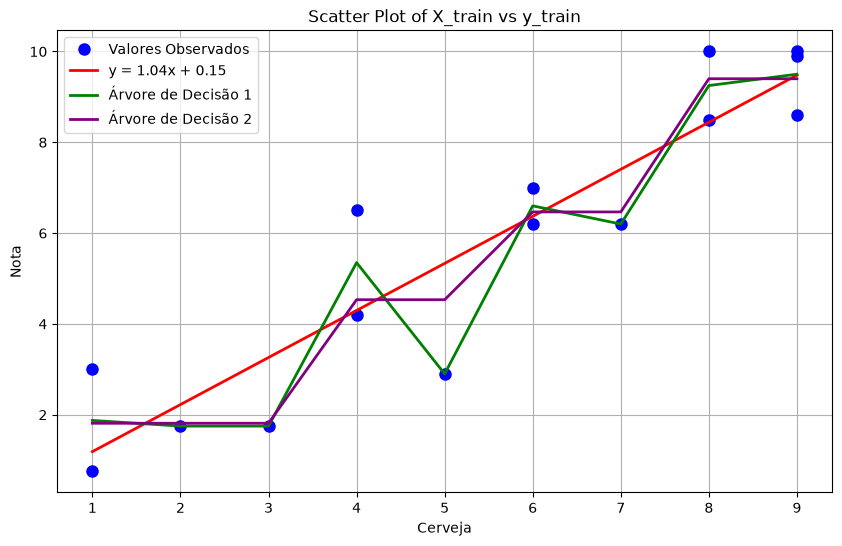

In [341]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(
    X_train,
    y_train,
    'o',
    markersize=8,
    color='blue'
)
plt.xlabel('Cerveja')
plt.ylabel('Nota')
plt.title('Scatter Plot of X_train vs y_train')
plt.grid(True)
plt.plot(
    X_train.drop_duplicates(),
    predict_reg,
    color='red',
    linewidth=2
)
plt.plot(
    X_train.drop_duplicates(),
    predict_tree_reg_1,
    color='green',
    linewidth=2
)
plt.plot(
    X_train.drop_duplicates(),
    predict_tree_reg_2,
    color='purple',
    linewidth=2
)
plt.legend([
    "Valores Observados",
    f"y = {regression_model.coef_[0]:.2f}x + {regression_model.intercept_:.2f}",
    "Árvore de Decisão 1",
    "Árvore de Decisão 2"
])
plt.show()

**A subida vertical da linha** da árvore de regressão é onde está sendo feito o corte e a **linha horizontal** representa os grupos/folhas da árvore. É possível observar que a árvore de decisão 1 está tentando decorar os dados, ou seja, está sofrendo de **overfitting**, enquanto a árvore de decisão 2 está generalizando melhor os dados.

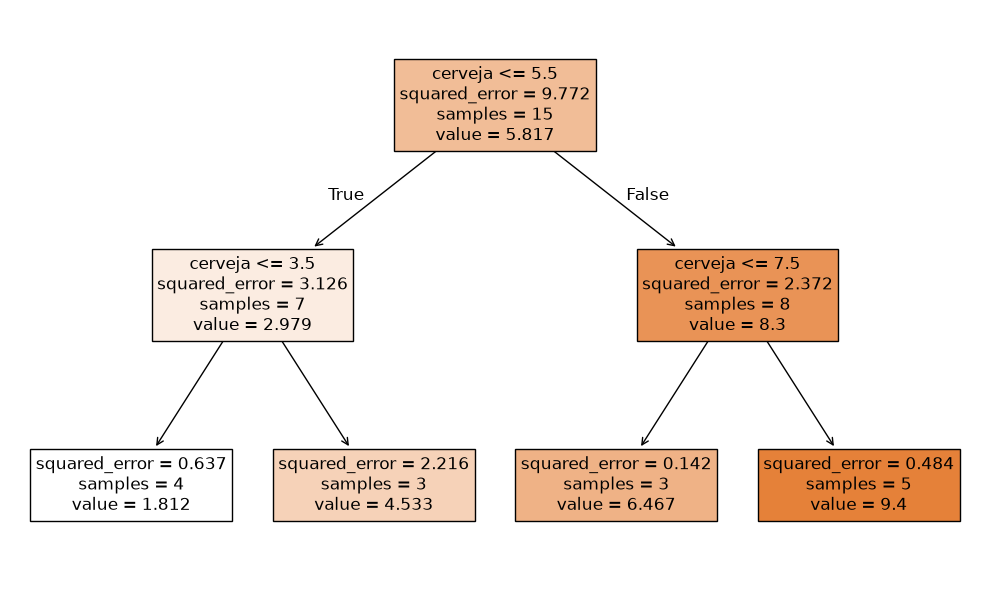

In [342]:
plt.figure(figsize=(10, 6), dpi=100)
tree.plot_tree(
    tree_reg_2,
    feature_names=X_train.columns.tolist(),
    filled=True,
    fontsize=12
)
plt.tight_layout()
plt.show()

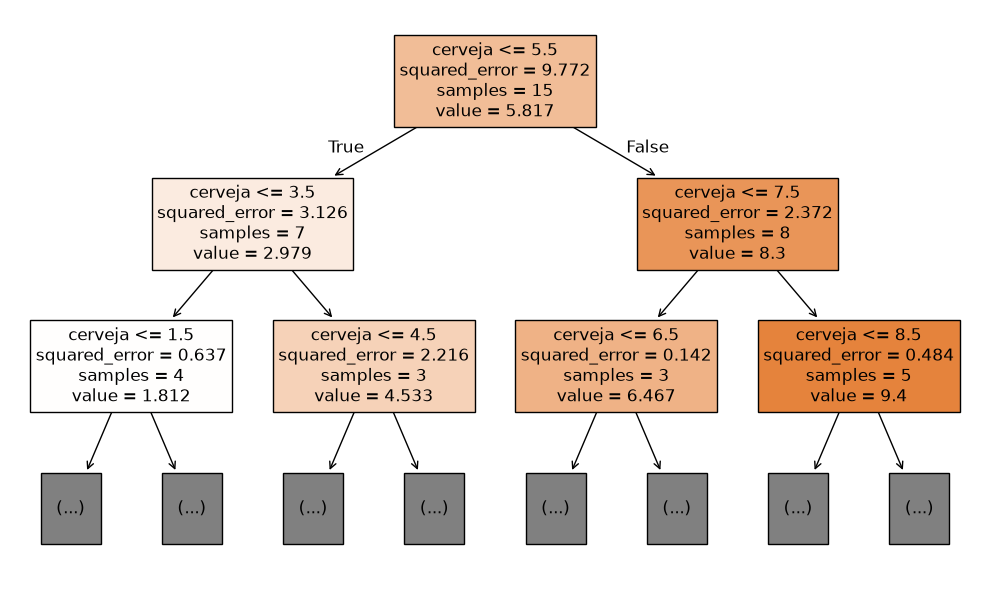

In [343]:
plt.figure(figsize=(10, 6), dpi=100)
tree.plot_tree(
    tree_reg_1,
    feature_names=X_train.columns.tolist(),
    filled=True,
    fontsize=12,
    max_depth=2
)
plt.tight_layout()
plt.show()

## Aula 10 - Algoritmos de classificação

Até o momento foi visto como usar algoritmos de regressão, mas também é possível usar algoritmos de classificação. A diferença entre os dois é que a regressão é usada para prever valores contínuos, enquanto a classificação é usada para classificar ou rotular em categorias/classes.

### Regressão Logística

A regressão logística é um algoritmo de classificação que é usado para prever a probabilidade de uma instância pertencer a uma classe específica. A saída da regressão logística é um valor entre 0 e 1 (binário), que representa a probabilidade de uma instância pertencer a uma classe.

A formula da regressão logística é:

$$y = \frac{1}{1 + e^{-(ax + b)}}$$

O log loss é uma métrica usada para avaliar a performance de um modelo de classificação. Ele mede a diferença entre as probabilidades previstas pelo modelo e as classes reais. Quanto menor o log loss, melhor o modelo está performando.

O log loss é calculado usando a seguinte fórmula:

$$ \text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1-y_i) \log(1-p_i)] $$

### Intervalo de confiança

Intervalo de confiança é uma faixa de valores que é usada para estimar a incerteza de uma previsão. Ele é calculado usando a média e o desvio padrão das previsões do modelo. O intervalo de confiança é geralmente representado como um intervalo de valores em torno da previsão, onde a probabilidade de a previsão real estar dentro desse intervalo é alta.

Digamos que temos um modelo de regressão logística que prevê a probabilidade de um paciente ter uma doença com base em seus sintomas. O modelo prevê que a probabilidade de um paciente ter a doença é de 0,7 (ou 70%). No entanto, sabemos que há incerteza nessa previsão, e queremos estimar o intervalo de confiança para essa previsão. Fazemos isso calculando a média e o desvio padrão das previsões do modelo em um conjunto de dados de validação. Suponha que a **média das previsões seja 0,7**, **desvio padrão seja 0,1** e que a **nossa amostra tenha 100 pacientes**, então o tamanho da amostra é n = 100. O valor **crítico Z** para um intervalo de confiança de 95% é aproximadamente 1,96. Substituindo esses valores na fórmula, temos:

$$ \text{Intervalo de Confiança} = \text{Média} \pm Z \times \frac{\text{Desvio Padrão}}{\sqrt{n}} $$

$$ \text{Intervalo de Confiança} = \text{0,7} \pm 1,96 \times \frac{0,1}{\sqrt{100}} $$

$$ \text{Intervalo de Confiança} = \text{0,7} \pm 1,96 \times 0,01 $$

$$ \text{Intervalo de Confiança} = \text{0,7} \pm 0,0196 $$

$$ \therefore$$

$$ \text{Intervalo de Confiança} = [0,6804, 0,7196] $$

Convertendo para porcentagem, temos que o intervalo de confiança é de (95%) 68,04% a 71,96%. Isso significa que estamos 95% confiantes de que a verdadeira probabilidade de um paciente ter a doença está entre 68% e 72%.

Podemos calcular também a incerteza da previsão individual usando a fórmula da variância da previsão. O modelo previu 0,7 (ou 70%) para um paciente específico. O desvio padrão da previsão é dado por:

$$ \text{Desvio Padrão} = 0,1 $$

$$ \text{Previsão Individual} = 0,7 \pm 1,96 \times 0,1 $$

$$ \text{Previsão Individual} = 0,7 \pm 0,196 $$

$$ \therefore$$

$$ \text{Previsão Individual} = [0,504, 0,896] \rightarrow [50,4\%, 89,6\%] $$

A diferença é que o primeiro usa o **erro padrão** e o segundo usa o **desvio padrão**. O erro padrão é uma medida da variabilidade da média das previsões, enquanto o desvio padrão é uma medida da variabilidade das previsões individuais. Na previsão individual é possível observar que o intervalo é mais amplo, o que significa que há mais incerteza na previsão individual do que na média das previsões. Isso é esperado, pois quando tira a média das previsões, o erro tende a diminuir, enquanto que na previsão individual, o erro tende a aumentar.


## Aula 11 - Métricas de avaliação para árvores de decisão

Na árvore de decisão, é possível usar métricas de avaliação para medir a performance do modelo. Uma métrica utilizada é o **gini** usado para medir a impureza de um nó na árvore de decisão. O índice de Gini varia de 0 a 1, onde 0 indica que todos as samples/instâncias pertencem a uma única classe, enquanto 1 indica que as samples/instâncias estão distribuídas igualmente entre todas as classes, ou seja, é mais impuro. A impureza de Gini é calculado usando a seguinte fórmula:

$$ Gini = 1 - \sum_{i=1}^{n} p_i^2 $$

Existe também o coeficiente de gini, muito usado para medir **desiguldade/dispersão** em valores númericos, como renda, patrimônio, concentração de mercado, etc. A fórmula do coeficiente de gini é:

$$ Gini = \frac{\sum_{i=1}^{n} \sum_{j=1}^{n} ||x_i - x_j||}{2n^2\bar{x}} $$

Ele mede o quanto os valores de $x$ são desiguais entre si, ou seja, quanto mais desigualdade houver entre os valores de $x$, maior será o coeficiente de gini. Basicamente, compara todo mundo com todo mundo, soma as diferenças e depois normaliza pela média.

Outra métrica de avaliação é a **entropia**, que mede a quantidade de informação contida em um nó da árvore de decisão. Em classificação, ela responde a pergunta: *"esse grupo de dados está puro ou tem várias classes misturadas"*. A fórmula da entropia é:

$$ Entropia = - \sum_{i=1}^{n} p_i \log_2(p_i) $$

## Aula 12 - Naive Bayes

O **naive bayes** é um algoritmo de classificação supervisionado baseado no teorema de Bayes, que é usado para calcular a probabilidade de uma instância pertencer a uma classe específica, dado um conjunto de features. O algoritmo assume que as features são independentes entre si, o que é uma simplificação (daí o nome "naive"). O Teorema de Bayes é uma fórmula matemática que descreve a probabilidade de um evento, com base em informações prévias sobre condições relacionadas ao evento. A fórmula do teorema de Bayes é:

$$ P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)} $$

Exemplo: qual é a probabilidade de um e-mail ser spam, sabendo que ele contém as palavras "grátis" e "promoção"? Imagine que queremos classificar um e-mail como:

- spam;
- normal.

Entretanto, foi observado uma evidência de que o e-mail contém a palavra "grátis". A probabilidade de um e-mail ser spam, dado que ele contém a palavra "grátis", é dada por:

$$ P(\text{spam}|\text{grátis}) = \frac{P(\text{grátis}|\text{spam}) \cdot P(\text{spam})}{P(\text{grátis})} $$

Vamos criar um cenário hipotético para calcular a probabilidade de um e-mail ser spam, dado que ele contém a palavra "grátis". Suponha que temos os seguintes dados:

<div align="center">

| Tipo de e-mail | Quantidade |
|----------------|------------|
| Spam           | 30         |
| Normal         | 70         |
| Total          | 100        |

</div>

$$ \therefore$$

$$ P(\text{spam}) = \frac{30}{100} = 0,3 $$

> Isso significa que antes de olhar o conteúdo do e-mail, a probabilidade de um e-mail ser spam é de 30%.

Essa probabilidade é chamada de **probabilidade a priori**.

Agora, olhamos a plavra "grátis", suponha que:

<div align="center">

| Tipo de e-mail | Quantidade de e-mails com a palavra "grátis" | Total |
|----------------|----------------------------------------------|-------|
| Spam           | 24                                           | 30    |
| Normal         | 7                                            | 70    |

$$ \therefore$$

$$ P(\text{grátis}|\text{spam}) = \frac{24}{30} = 0,8 $$

</div>

> Entre os e-mails que são spam, 80% deles contém a palavra "grátis".

Qual é a probabilidade de um e-mail qualquer conter a palavra "grátis"? Temos dois caminhos nesse caso, ou seja, o e-mail pode ser spam ou normal. Então:

- pode ser **spam** e ter **grátis**;
- pode ser **normal** e ter **grátis**.

$$ P(\text{grátis}) = P(\text{grátis}|\text{spam}) \cdot P(\text{spam}) + P(\text{grátis}|\text{normal}) \cdot P(\text{normal}) $$

substituindo os valores, temos:

$$ P(\text{grátis}) = 0,8 \cdot 0,3 + 0,1 \cdot 0,7 $$

$$ P(\text{grátis}) = 0,24 + 0,07 $$

$$ P(\text{grátis}) = 0,31 $$

$$ \therefore$$

$$ P(\text{spam}|\text{grátis}) = \frac{0,8 \cdot 0,3}{0,31} $$

$$ P(\text{spam}|\text{grátis}) = \frac{0,24}{0,31} $$

$$ P(\text{spam}|\text{grátis}) \approx 0,7742 $$

$$ \therefore$$

$$ P(\text{spam}|\text{grátis}) \approx 77,42\% $$

Podemos também calcular a probabilidade de um e-mail ser normal, dado que ele contém a palavra "grátis":

$$ P(\text{normal}|\text{grátis}) = \frac{P(\text{grátis}|\text{normal}) \cdot P(\text{normal})}{P(\text{grátis})} $$

$$ P(\text{normal}|\text{grátis}) = \frac{0,1 \cdot 0,7}{0,31} $$

$$ P(\text{normal}|\text{grátis}) = \frac{0,07}{0,31} $$

$$ P(\text{normal}|\text{grátis}) \approx 0,2258 $$

$$ \therefore$$

$$ P(\text{normal}|\text{grátis}) \approx 22,58\% $$

Em *Machine Learning*, normalmente temos várias features, por exemplo: 

- "grátis";
- "promoção";
- "desconto";

A pergunta vira:

$$ P(\text{spam}|\text{grátis}, \text{promoção}, \text{desconto}) $$

Só que calcular isso diretamente é muito difícil, então usamos a **independência condicional** para simplificar o cálculo. A independência condicional assume que as features são independentes entre si, dado a classe. Então podemos escrever:

$$ P(\text{spam}|\text{grátis}, \text{promoção}, \text{desconto}) = \frac{P(\text{grátis}|\text{spam}) \cdot P(\text{promoção}|\text{spam}) \cdot P(\text{desconto}|\text{spam}) \cdot P(\text{spam})}{P(\text{grátis}, \text{promoção}, \text{desconto})} $$

$$ P(\text{normal}|\text{grátis}, \text{promoção}, \text{desconto}) = \frac{P(\text{grátis}|\text{normal}) \cdot P(\text{promoção}|\text{normal}) \cdot P(\text{desconto}|\text{normal}) \cdot P(\text{normal})}{P(\text{grátis}, \text{promoção}, \text{desconto})} $$

Depois ele compara as duas probabilidades e escolhe a maior, ou seja, a classe com maior probabilidade é a classe prevista pelo modelo.

## Aula 13 - Práticando classificação

In [344]:
data_path = Path.cwd() / "data" / "dados_cerveja_nota.xlsx"
df = pd.read_excel(data_path)
df = df.set_index("id")

In [345]:
# Notas maiores que 5
df["aprovado"] = (df["nota"] > 5).astype(int)
df["aprovado"].value_counts()

aprovado
1    9
0    6
Name: count, dtype: int64

In [346]:
df

,cerveja,nota,aprovado
id,,,
1,1,0.75,0
2,1,3.00,0
3,2,1.75,0
4,3,1.75,0
5,4,4.20,0
6,4,6.50,1
7,5,2.90,0
8,6,6.20,1
9,6,7.00,1


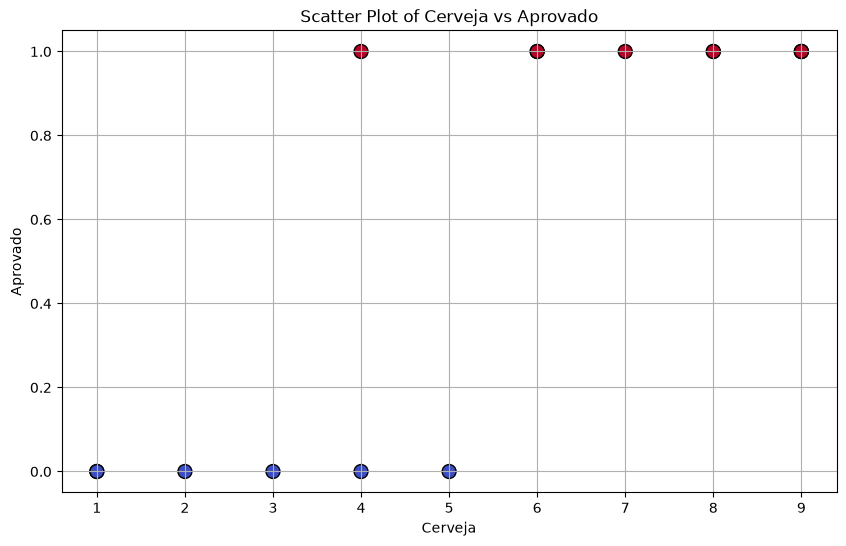

In [347]:
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.title('Scatter Plot of Cerveja vs Aprovado')
plt.grid(True)
plt.show()

In [348]:
from sklearn.linear_model import LogisticRegression

# Modelo de regressão logística
model_regression = LogisticRegression(penalty=None, fit_intercept=True)
model_regression.fit(df[["cerveja"]], df["aprovado"])

# Modelo de árvore de decisão
model_tree = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
model_tree.fit(df[["cerveja"]], df["aprovado"])

d:\projetos\machine_learning_study\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [349]:
model_regression.coef_, model_regression.intercept_

(array([[1.61079215]]), array([-7.49445802]))

In [350]:
model_predict = model_regression.predict(df[["cerveja"]].drop_duplicates())

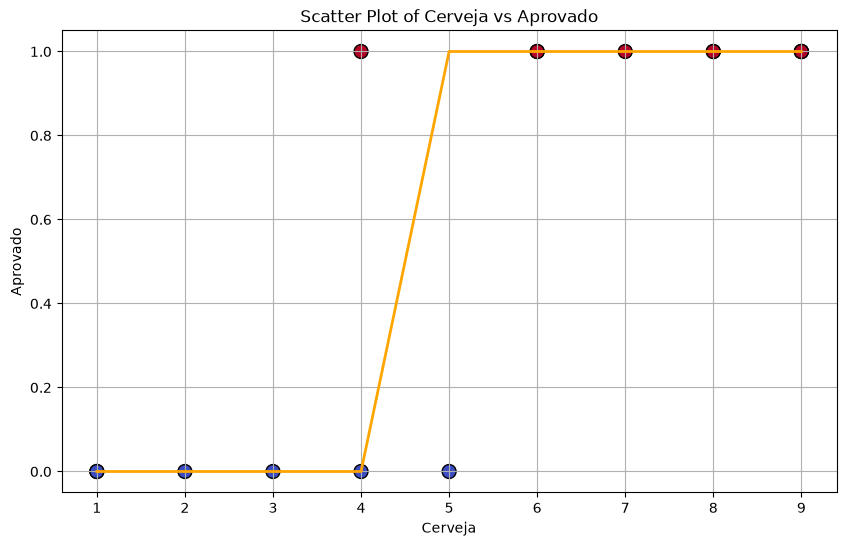

In [351]:
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.title('Scatter Plot of Cerveja vs Aprovado')
plt.grid(True)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_predict,
    color='orange',
    linewidth=2
)
plt.show()

É possível observar que o modelo de regressão logística está tentando encontrar a melhor linha que separa os dados em duas classes, ou seja, está tentando encontrar a melhor fronteira de decisão. A linha laranja é a fronteira de decisão do modelo. Entretanto, é possível observar que o modelo está errando em 4 e 5. O 4 é um problema porque existe **dois valores reais (dados de entrada do dataset)** com respostas diferentes, ou seja, quando **registro A** é 4, a resposta é 0, mas quando **registro B** é 4, a resposta é 1. Como o modelo só tem a feature `cerveja`, ele não tem informação suficiente para separar esses dois casos. Para `cerveja = 4`, ele precisa dar uma única previsão. Então, ele obrigatoriamente vai errar em um dos casos. O 5 é um problema porque o modelo definiu uma fronteira de decisão mais ou menos assim: **cerveja < 5 = 0 e cerveja >= 5 = 1**, ou seja, quando chega em `cerveja = 5`, o modelo já coloca esse ponto no lado dos aprovados, mas o valor real é 0. Isso acontece porque o modelo está tentando encontrar a melhor linha que separa os dados em duas classes, mas não tem informação suficiente para separar esses dois casos.

In [352]:
model_predict = model_regression.predict(df[["cerveja"]].drop_duplicates())
model_predict_proba = model_regression.predict_proba(df[["cerveja"]].drop_duplicates())[:, 1]


model_tree_predict = model_tree.predict(df[["cerveja"]].drop_duplicates())
model_tree_predict_proba = pd.DataFrame(
    model_tree.predict_proba(df[["cerveja"]].drop_duplicates()),
    columns=model_tree.classes_
)[1]


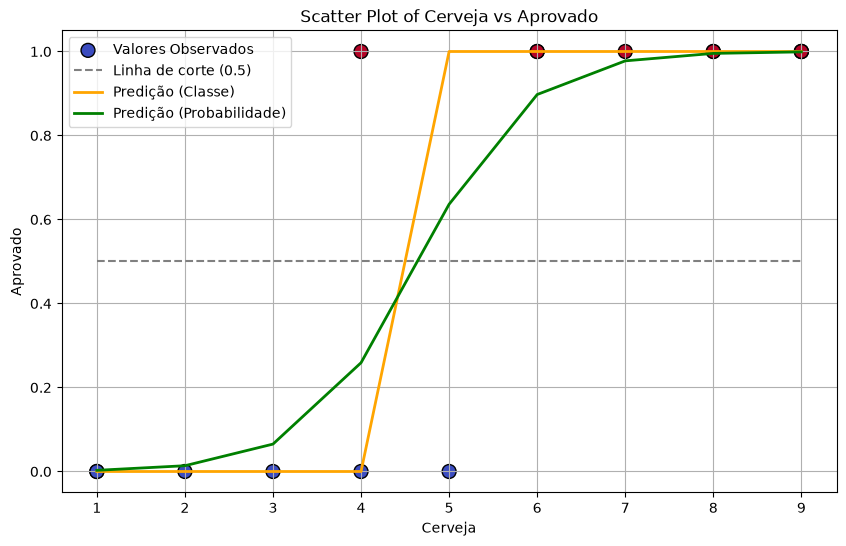

In [353]:
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.title('Scatter Plot of Cerveja vs Aprovado')
plt.grid(True)
plt.hlines(
    y=0.5,
    xmin=df["cerveja"].min(),
    xmax=df["cerveja"].max(),
    colors='gray',
    linestyles='dashed'
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_predict,
    color='orange',
    linewidth=2
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_predict_proba,
    color='green',
    linewidth=2
)
plt.legend([
    "Valores Observados",
    "Linha de corte (0.5)",
    "Predição (Classe)",
    "Predição (Probabilidade)"
])
plt.show()

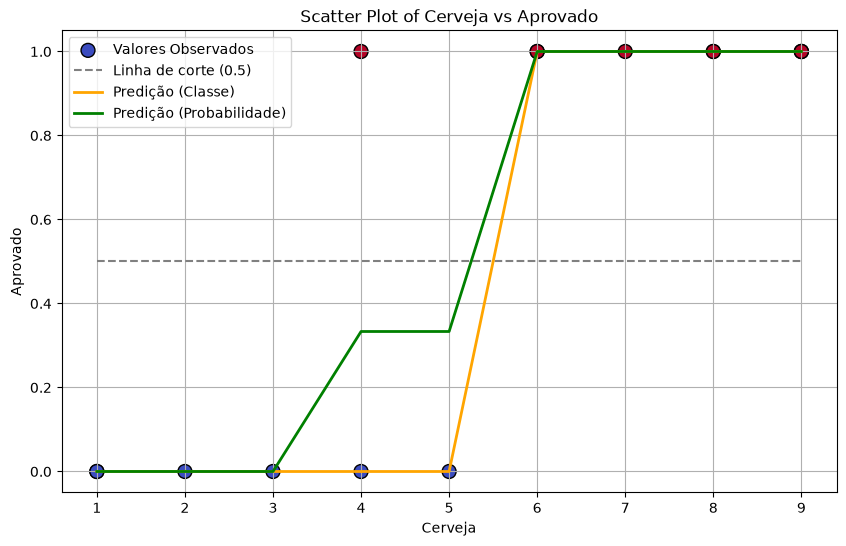

In [ ]:
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.title('Scatter Plot of Cerveja vs Aprovado')
plt.grid(True)
plt.hlines(
    y=0.5,
    xmin=df["cerveja"].min(),
    xmax=df["cerveja"].max(),
    colors='gray',
    linestyles='dashed'
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_tree_predict,
    color='orange',
    linewidth=2
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_tree_predict_proba,
    color='green',
    linewidth=2
)
plt.legend([
    "Valores Observados",
    "Linha de corte (0.5)",
    "Predição (Classe)",
    "Predição (Probabilidade)"
])
plt.show()

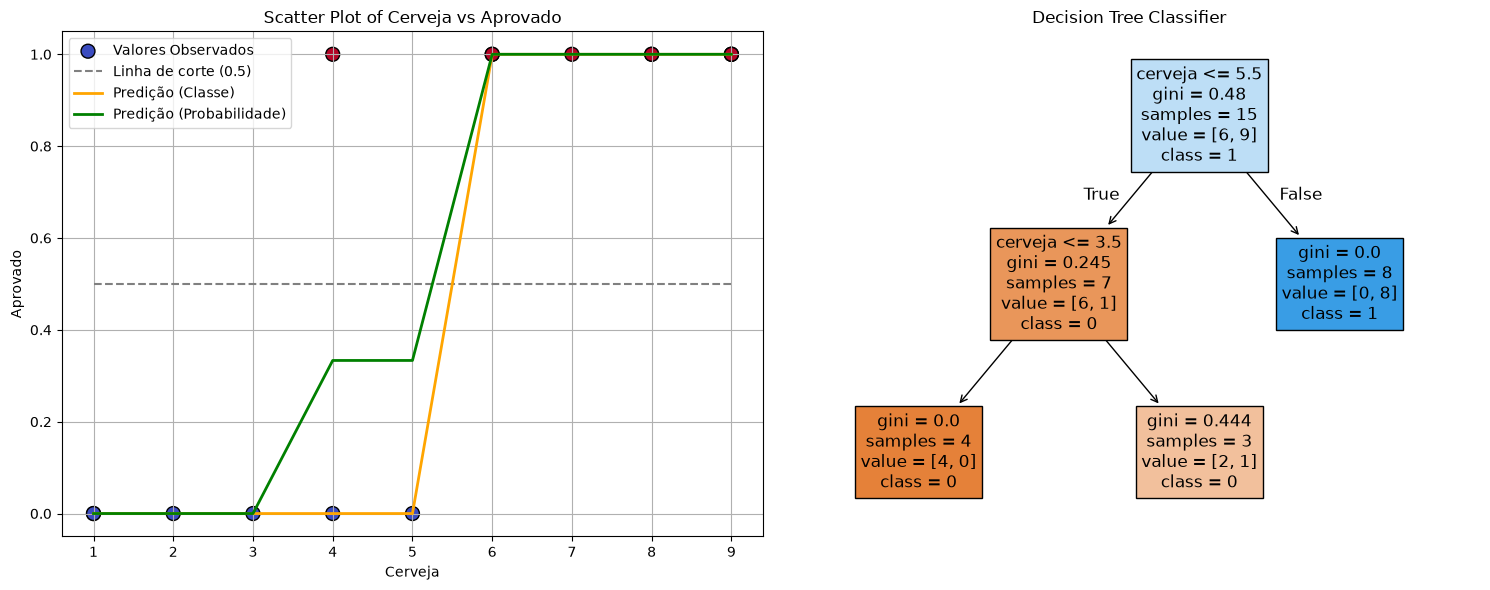

In [ ]:
class_names = [str(classe) for classe in model_tree.classes_]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), dpi=100)

# Plotting no regressão logística no primeiro subplot
axes[0].scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
axes[0].set_xlabel('Cerveja')
axes[0].set_ylabel('Aprovado')
axes[0].set_title('Scatter Plot of Cerveja vs Aprovado')
axes[0].grid(True)
axes[0].hlines(
    y=0.5,
    xmin=df["cerveja"].min(),
    xmax=df["cerveja"].max(),
    colors='gray',
    linestyles='dashed'
)
axes[0].plot(
    df[["cerveja"]].drop_duplicates(),
    model_tree_predict,
    color='orange',
    linewidth=2
)
axes[0].plot(
    df[["cerveja"]].drop_duplicates(),
    model_tree_predict_proba,
    color='green',
    linewidth=2
)
axes[0].legend([
    "Valores Observados",
    "Linha de corte (0.5)",
    "Predição (Classe)",
    "Predição (Probabilidade)"
])

# Plotting árvore de decisão no segundo subplot
tree.plot_tree(
    model_tree,
    feature_names=df[["cerveja"]].drop_duplicates().columns.tolist(),
    class_names=class_names,
    filled=True,
    fontsize=12,
    ax=axes[1]
)

axes[1].set_title('Decision Tree Classifier')

plt.tight_layout()
plt.show()

In [373]:
from sklearn.naive_bayes import GaussianNB

# Criando um modelo Naive Bayes
model_nb = GaussianNB()
model_nb.fit(df[["cerveja"]], df["aprovado"])

# Trainando o modelo Naive Bayes
model_nb_predict = model_nb.predict(df[["cerveja"]].drop_duplicates())
model_nb_predict_proba = model_nb.predict_proba(df[["cerveja"]].drop_duplicates())[:, 1]

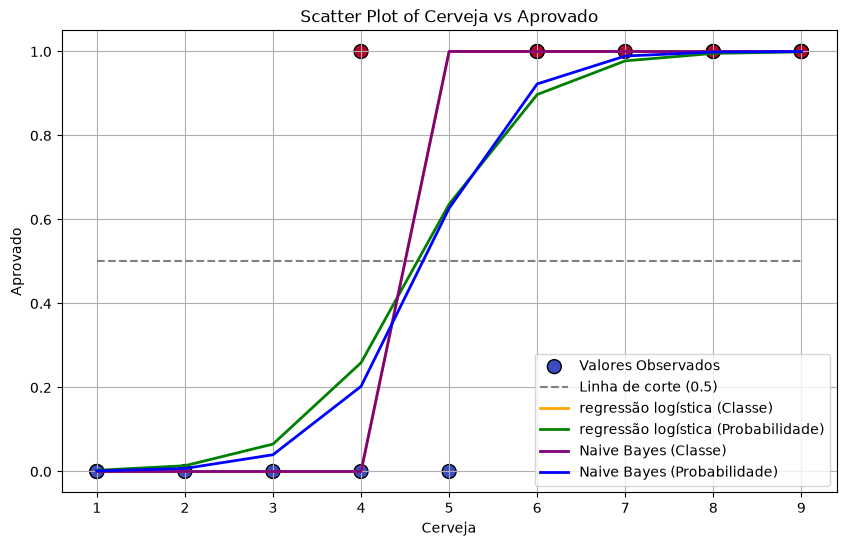

In [381]:
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(
    df["cerveja"],
    df["aprovado"],
    c=df["aprovado"],
    cmap="coolwarm",
    edgecolor="k",
    s=100
)
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.title('Scatter Plot of Cerveja vs Aprovado')
plt.grid(True)
plt.hlines(
    y=0.5,
    xmin=df["cerveja"].min(),
    xmax=df["cerveja"].max(),
    colors='gray',
    linestyles='dashed'
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_predict,
    color='orange',
    linewidth=2
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_predict_proba,
    color='green',
    linewidth=2
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_nb_predict,
    color='purple',
    linewidth=2
)
plt.plot(
    df[["cerveja"]].drop_duplicates(),
    model_nb_predict_proba,
    color='blue',
    linewidth=2
)
plt.legend([
    "Valores Observados",
    "Linha de corte (0.5)",
    "regressão logística (Classe)",
    "regressão logística (Probabilidade)",
    "Naive Bayes (Classe)",
    "Naive Bayes (Probabilidade)"
])
plt.show()

É possível observar que o modelo **Naive Bayes** apresenta uma probabilidade maior de acerto do que o modelo de **regressão logística**, pois a linha azul (Naive Bayes) está mais próxima dos valores reais do que a linha verde (regressão logística), ou seja, quando `cerveja <=5`, o modelo Naive Bayes tem uma probabilidade maior de `aprovado = 0` e quando `cerveja >= 6`, o modelo tem uma probabilidade maior de `aprovado = 1`.

## Aula 14 - Métrica de ajuste (prática)

Alguns tópicos abordados nessa aula:
- matriz de confusão;
- acurácia;
- precisão;
- recall;
- curva ROC.